In [1]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
# Load the same development sample used in Notebook 03

df = pd.read_csv("../../data/samples/criteo_sample.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

Rows: 139796
Columns: 16


In [3]:
#define modelling columns
FEATURES = [
    "f0", "f1", "f2", "f3",
    "f4", "f5", "f6", "f7",
    "f8", "f9", "f10", "f11"
]

TREATMENT_COL = "treatment"
LABEL_COL = "conversion"

In [4]:
#recreate the same balanced sample
df_treat = df[df[TREATMENT_COL] == 1].copy()
df_ctrl = df[df[TREATMENT_COL] == 0].copy()

df_treat_ds = df_treat.sample(
    n=len(df_ctrl),
    random_state=42
)

df_balanced = (
    pd.concat([df_treat_ds, df_ctrl], axis=0)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print(df_balanced[TREATMENT_COL].value_counts())

treatment
0    21048
1    21048
Name: count, dtype: int64


In [5]:
#Recreate the same stratified train/test split
from sklearn.model_selection import train_test_split

strata = (
    df_balanced[TREATMENT_COL].astype(str)
    + "_"
    + df_balanced[LABEL_COL].astype(str)
)

train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.20,
    stratify=strata,
    random_state=42
)

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

Training rows: 33676
Test rows: 8420


In [6]:
#What does uplift by decile look like when there is no predictive signal?
# Generate a random score for every test customer

rng = np.random.RandomState(42)

test_random = test_df.copy()

test_random["random_score"] = rng.random(
    len(test_random)
)

print(test_random["random_score"].describe())

count    8420.000000
mean        0.494446
std         0.288662
min         0.000012
25%         0.243343
50%         0.492622
75%         0.742325
max         0.999718
Name: random_score, dtype: float64


In [7]:
#create random score deciles
test_random["random_decile"] = pd.qcut(
    test_random["random_score"],
    q=10,
    labels=False,
    duplicates="drop"
)

print(
    test_random["random_decile"]
    .value_counts()
    .sort_index()
)

random_decile
0    842
1    842
2    842
3    842
4    842
5    842
6    842
7    842
8    842
9    842
Name: count, dtype: int64


In [8]:
#calculate observed uplift for random baseline
random_results = []

for decile, group in test_random.groupby(
    "random_decile",
    observed=True
):

    treatment_group = group[
        group[TREATMENT_COL] == 1
    ]

    control_group = group[
        group[TREATMENT_COL] == 0
    ]

    treatment_rate = treatment_group[LABEL_COL].mean()
    control_rate = control_group[LABEL_COL].mean()

    observed_uplift = (
        treatment_rate - control_rate
    )

    random_results.append({
        "random_decile": decile,
        "customers": len(group),
        "treatment_customers": len(treatment_group),
        "control_customers": len(control_group),
        "treatment_conversions": treatment_group[LABEL_COL].sum(),
        "control_conversions": control_group[LABEL_COL].sum(),
        "treatment_conversion_rate": treatment_rate,
        "control_conversion_rate": control_rate,
        "observed_uplift": observed_uplift
    })

random_tbl = pd.DataFrame(random_results)

In [9]:
#rank the random deciles
random_tbl = (
    random_tbl
    .sort_values(
        "random_decile",
        ascending=False
    )
    .reset_index(drop=True)
)

random_tbl["rank"] = np.arange(
    1,
    len(random_tbl) + 1
)

random_tbl

,random_decile,customers,treatment_customers,control_customers,treatment_conversions,control_conversions,treatment_conversion_rate,control_conversion_rate,observed_uplift,rank
0,9,842,408,434,4,3,0.009804,0.006912,0.002891,1
1,8,842,395,447,0,0,0.000000,0.000000,0.000000,2
2,7,842,427,415,1,0,0.002342,0.000000,0.002342,3
3,6,842,422,420,2,1,0.004739,0.002381,0.002358,4
4,5,842,434,408,0,0,0.000000,0.000000,0.000000,5
5,4,842,404,438,1,1,0.002475,0.002283,0.000192,6
6,3,842,429,413,3,0,0.006993,0.000000,0.006993,7
7,2,842,412,430,0,1,0.000000,0.002326,-0.002326,8
8,1,842,430,412,2,1,0.004651,0.002427,0.002224,9
9,0,842,449,393,0,0,0.000000,0.000000,0.000000,10


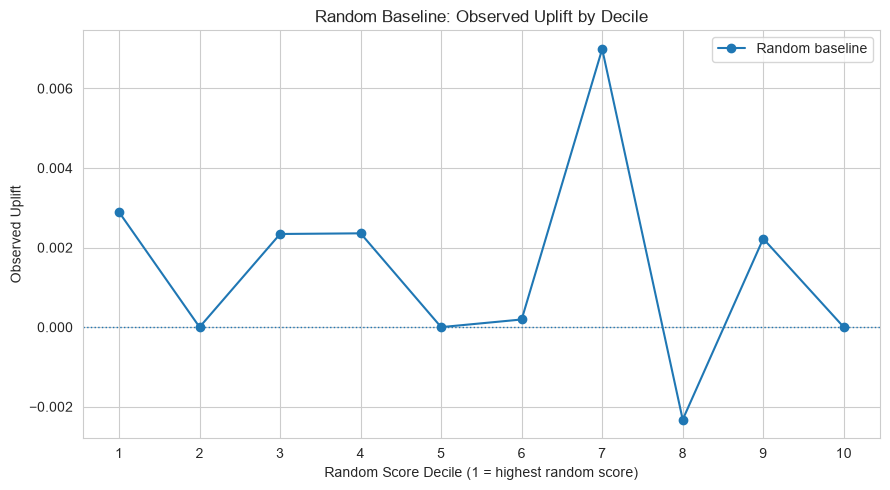

In [10]:
#plot the random baseline
plt.figure(figsize=(9, 5))

plt.plot(
    random_tbl["rank"],
    random_tbl["observed_uplift"],
    marker="o",
    label="Random baseline"
)

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

plt.xlabel(
    "Random Score Decile (1 = highest random score)"
)

plt.ylabel(
    "Observed Uplift"
)

plt.title(
    "Random Baseline: Observed Uplift by Decile"
)

plt.xticks(range(1, 11))

plt.legend()

plt.tight_layout()
plt.show()

**Random Baseline Evaluation**

A random score was assigned to each test-set observation and used to divide customers into ten deciles. This provides a **non-predictive benchmark** for evaluating the T-Learner.
Observed uplift across the random deciles fluctuates between approximately **-0.0023 and +0.0070**, with no consistent pattern across decile rank. For example, uplift reaches approximately **0.0070** in Decile 7, drops to **-0.0023** in Decile 8, and rises again to **0.0022** in Decile 9.

This lack of monotonicity is expected from a random ranking. The variation across deciles is primarily attributable to **sampling noise**, particularly given the small number of conversion events in the test set.
Overall, the test-set treatment conversion rate is approximately **0.3088%**, compared with **0.1663%** for control, giving an observed uplift of approximately **0.1425 percentage points**. The random baseline therefore provides a reference for determining whether the T-Learner can identify customers with higher incremental response.

**Main Takeaway**

The random baseline shows **no systematic relationship between decile rank and observed uplift**. The fluctuations across deciles should therefore be interpreted as sampling variation rather than meaningful evidence of customer-level uplift heterogeneity.

The corrected T-Learner will be compared against this baseline to assess whether its predicted-uplift ranking provides meaningful targeting value beyond random ranking.


In [11]:
# Separate training data into treatment and control groups

train_t = train_df[
    train_df[TREATMENT_COL] == 1
].copy()

train_c = train_df[
    train_df[TREATMENT_COL] == 0
].copy()

print("Treatment training rows:", len(train_t))
print("Control training rows:", len(train_c))

Treatment training rows: 16838
Control training rows: 16838


In [12]:
from sklearn.linear_model import LogisticRegression

# Train treatment model without class weighting

model_treatment_v2 = LogisticRegression(
    max_iter=1000
)

model_treatment_v2.fit(
    train_t[FEATURES],
    train_t[LABEL_COL]
)

print("Treatment model v2 trained successfully.")

Treatment model v2 trained successfully.


In [13]:
# Train control model without class weighting
model_control_v2 = LogisticRegression(
    max_iter=1000
)

model_control_v2.fit(
    train_c[FEATURES],
    train_c[LABEL_COL]
)

print("Control model v2 trained successfully.")

Control model v2 trained successfully.


In [14]:
# Predict probability under treatment
p_treatment_v2 = model_treatment_v2.predict_proba(
    test_df[FEATURES]
)[:, 1]

print(
    "Treatment predictions generated:",
    len(p_treatment_v2)
)

Treatment predictions generated: 8420


In [15]:
# Predict probability under control
p_control_v2 = model_control_v2.predict_proba(
    test_df[FEATURES]
)[:, 1]

print(
    "Control predictions generated:",
    len(p_control_v2)
)

Control predictions generated: 8420


In [16]:
# Calculate v2 predicted uplift
test_v2 = test_df.copy()

test_v2["p_treatment"] = p_treatment_v2
test_v2["p_control"] = p_control_v2

test_v2["uplift"] = (
    test_v2["p_treatment"]
    - test_v2["p_control"]
)

print("V2 uplift calculated successfully.")
print(
    test_v2["uplift"].describe()
)
print(
    "Minimum uplift:",
    test_v2["uplift"].min()
)

print(
    "Maximum uplift:",
    test_v2["uplift"].max()
)

V2 uplift calculated successfully.
count    8420.000000
mean        0.000739
std         0.010802
min        -0.497766
25%         0.000204
50%         0.000288
75%         0.000642
max         0.224732
Name: uplift, dtype: float64
Minimum uplift: -0.49776634791365715
Maximum uplift: 0.22473215681964812


**Model v2 Performance: Removing Class Weighting**

Removing `class_weight="balanced"` substantially reduced the predicted uplift magnitudes compared to the original T-learner, bringing the central distribution much closer to reality while keeping the core metrics grounded:

* **Central Distribution Metrics**
    - **Mean predicted uplift:** ~0.00073
    - **Median predicted uplift:** ~0.000288
    - **Interquartile range (IQR):** ~0.000204 to ~0.000642


* **Remaining Vulnerabilities**
    - **Extreme individual predictions:** The model still predicts values ranging from **-0.498 to +0.225**.
    - **Discrepancy with reality:** These extremes far exceed the observed test set conversion rate of **~0.24%**, indicating that further regularization is necessary.


**Next Steps**
Compare different levels of logistic regression regularization (**C = 1.0**, **0.1**, and **0.01**) to test whether stronger penalties produce more stable and realistic uplift estimates.

In [17]:
#train model with different c value
C_VALUES = [1.0, 0.1, 0.01]

regularization_results = []

for C in C_VALUES:

    model_t = LogisticRegression(
        C=C,
        max_iter=1000
    )

    model_c = LogisticRegression(
        C=C,
        max_iter=1000
    )

    model_t.fit(
        train_t[FEATURES],
        train_t[LABEL_COL]
    )

    model_c.fit(
        train_c[FEATURES],
        train_c[LABEL_COL]
    )

    p_t = model_t.predict_proba(
        test_df[FEATURES]
    )[:, 1]

    p_c = model_c.predict_proba(
        test_df[FEATURES]
    )[:, 1]

    uplift = p_t - p_c

    regularization_results.append({
        "C": C,
        "min_uplift": uplift.min(),
        "max_uplift": uplift.max(),
        "mean_uplift": uplift.mean(),
        "median_uplift": np.median(uplift),
        "std_uplift": uplift.std()
    })

regularization_tbl = pd.DataFrame(
    regularization_results
)

regularization_tbl

,C,min_uplift,max_uplift,mean_uplift,median_uplift,std_uplift
0,1.00,-0.497766,0.224732,0.000739,0.000288,0.010801
1,0.10,-0.249724,0.120138,0.000865,0.000320,0.005899
2,0.01,-0.020426,0.111313,0.000954,0.000337,0.003275


**Regularization Comparison Findings**

* **C = 1.0 (Weak):** High dispersion (standard deviation: 0.010801) with severe negative outliers (minimum around -0.498).
* **C = 0.1 (Moderate):** Moderate spread reduction (standard deviation: 0.005899, minimum around -0.250).
* **C = 0.01 (Strong):** Best stability (standard deviation: 0.003275, minimum around -0.020, median around 0.000337).

**Summary and Next Steps**

* **Impact of Regularization:** Increasing regularization (using a lower $C$ value) effectively controls extreme predictions and shrinks uplift variance.
* **Calibration Limits:** While $C = 0.01$ yields the most stable distribution, maximum predictions remain larger than actual conversion rates, indicating that regularization alone does not fully resolve calibration issues.
* **Selection:** $C = 0.01$ is chosen as the optimal setting for downstream evaluation with standardized features against the random baseline.

In [18]:
from sklearn.preprocessing import StandardScaler
# Fit scaler on the complete training feature set and apply the same transformation to treatment, control, and test data.

scaler = StandardScaler()

X_train = scaler.fit_transform(
    train_df[FEATURES]
)

X_train_t = scaler.transform(
    train_t[FEATURES]
)

X_train_c = scaler.transform(
    train_c[FEATURES]
)

X_test = scaler.transform(
    test_df[FEATURES]
)

print("Feature scaling completed.")
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Feature scaling completed.
Training shape: (33676, 12)
Test shape: (8420, 12)


In [19]:
#set the final regularization
FINAL_C = 0.01

print("Final C:", FINAL_C)

Final C: 0.01


In [20]:
# train the final treatment model
model_treatment_final = LogisticRegression(
    C=FINAL_C,
    max_iter=1000
)

model_treatment_final.fit(
    X_train_t,
    train_t[LABEL_COL]
)

print("Final treatment model trained successfully.")

Final treatment model trained successfully.


In [21]:
#train the final control model
model_control_final = LogisticRegression(
    C=FINAL_C,
    max_iter=1000
)

model_control_final.fit(
    X_train_c,
    train_c[LABEL_COL]
)

print("Final control model trained successfully.")

Final control model trained successfully.


In [22]:
# Generate final predictions

#treatment probability
p_treatment_final = (
    model_treatment_final
    .predict_proba(X_test)[:, 1]
)

print(
    "Treatment predictions generated:",
    len(p_treatment_final)
)

#control probability
p_control_final = (
    model_control_final
    .predict_proba(X_test)[:, 1]
)

print(
    "Control predictions generated:",
    len(p_control_final)
)

Treatment predictions generated: 8420
Control predictions generated: 8420


In [23]:
#calculate final prediction uplift
test_final = test_df.copy()

test_final["p_treatment"] = p_treatment_final
test_final["p_control"] = p_control_final

test_final["uplift"] = (
    test_final["p_treatment"]
    - test_final["p_control"]
)

print("Final uplift calculated successfully.")

print(
    test_final["uplift"].describe()
)

print(
    "Minimum uplift:",
    test_final["uplift"].min()
)

print(
    "Maximum uplift:",
    test_final["uplift"].max()
)

Final uplift calculated successfully.
count    8420.000000
mean        0.001110
std         0.005198
min        -0.168957
25%         0.000354
50%         0.000428
75%         0.000640
max         0.185859
Name: uplift, dtype: float64
Minimum uplift: -0.16895654832839185
Maximum uplift: 0.1858585682756504


In [24]:
#create the final uplift deciles
test_final["uplift_decile"] = pd.qcut(
    test_final["uplift"],
    q=10,
    labels=False,
    duplicates="drop"
)

print(
    test_final["uplift_decile"]
    .value_counts()
    .sort_index()
)

uplift_decile
0    842
1    842
2    842
3    842
4    842
5    842
6    842
7    842
8    842
9    842
Name: count, dtype: int64


In [25]:
#calculate observed uplift
final_results = []

for decile, group in test_final.groupby(
    "uplift_decile",
    observed=True
):

    treatment_group = group[
        group[TREATMENT_COL] == 1
    ]

    control_group = group[
        group[TREATMENT_COL] == 0
    ]

    treatment_rate = treatment_group[LABEL_COL].mean()
    control_rate = control_group[LABEL_COL].mean()

    observed_uplift = (
        treatment_rate - control_rate
    )

    predicted_uplift = group["uplift"].mean()

    final_results.append({
        "uplift_decile": decile,
        "customers": len(group),
        "treatment_customers": len(treatment_group),
        "control_customers": len(control_group),
        "treatment_conversions": treatment_group[LABEL_COL].sum(),
        "control_conversions": control_group[LABEL_COL].sum(),
        "treatment_conversion_rate": treatment_rate,
        "control_conversion_rate": control_rate,
        "observed_uplift": observed_uplift,
        "predicted_uplift": predicted_uplift
    })

final_decile_tbl = pd.DataFrame(final_results)

final_decile_tbl

,uplift_decile,customers,treatment_customers,control_customers,treatment_conversions,control_conversions,treatment_conversion_rate,control_conversion_rate,observed_uplift,predicted_uplift
0,0,842,422,420,3,0,0.007109,0.000000,0.007109,-0.000270
1,1,842,451,391,0,0,0.000000,0.000000,0.000000,0.000322
2,2,842,391,451,0,0,0.000000,0.000000,0.000000,0.000353
3,3,842,398,444,0,0,0.000000,0.000000,0.000000,0.000378
4,4,842,394,448,0,0,0.000000,0.000000,0.000000,0.000407
5,5,842,416,426,0,0,0.000000,0.000000,0.000000,0.000452
6,6,842,439,403,1,0,0.002278,0.000000,0.002278,0.000518
7,7,842,419,423,0,1,0.000000,0.002364,-0.002364,0.000650
8,8,842,439,403,1,1,0.002278,0.002481,-0.000203,0.001077
9,9,842,441,401,8,5,0.018141,0.012469,0.005672,0.007212


In [26]:
#rank the deciles
final_decile_tbl = (
    final_decile_tbl
    .sort_values(
        "uplift_decile",
        ascending=False
    )
    .reset_index(drop=True)
)

final_decile_tbl["rank"] = np.arange(
    1,
    len(final_decile_tbl) + 1
)

final_decile_tbl

,uplift_decile,customers,treatment_customers,control_customers,treatment_conversions,control_conversions,treatment_conversion_rate,control_conversion_rate,observed_uplift,predicted_uplift,rank
0,9,842,441,401,8,5,0.018141,0.012469,0.005672,0.007212,1
1,8,842,439,403,1,1,0.002278,0.002481,-0.000203,0.001077,2
2,7,842,419,423,0,1,0.000000,0.002364,-0.002364,0.000650,3
3,6,842,439,403,1,0,0.002278,0.000000,0.002278,0.000518,4
4,5,842,416,426,0,0,0.000000,0.000000,0.000000,0.000452,5
5,4,842,394,448,0,0,0.000000,0.000000,0.000000,0.000407,6
6,3,842,398,444,0,0,0.000000,0.000000,0.000000,0.000378,7
7,2,842,391,451,0,0,0.000000,0.000000,0.000000,0.000353,8
8,1,842,451,391,0,0,0.000000,0.000000,0.000000,0.000322,9
9,0,842,422,420,3,0,0.007109,0.000000,0.007109,-0.000270,10


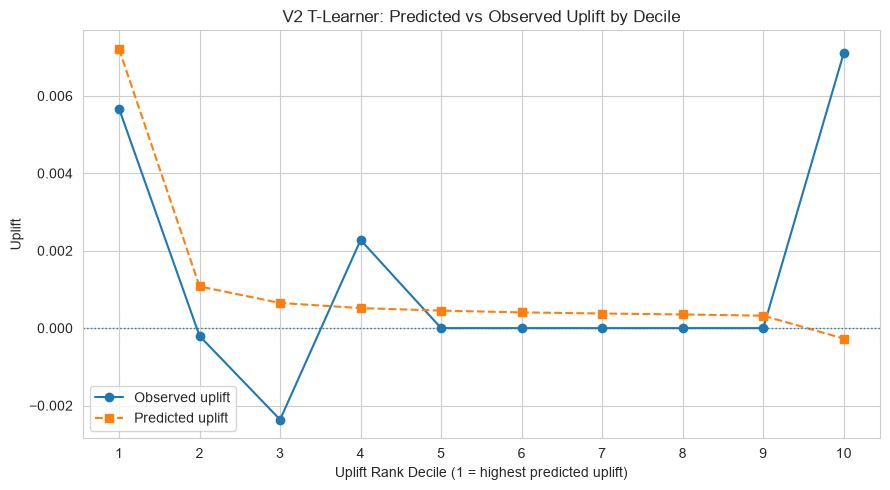

In [27]:
#plot predicted vs observed uplift
plt.figure(figsize=(9, 5))

plt.plot(
    final_decile_tbl["rank"],
    final_decile_tbl["observed_uplift"],
    marker="o",
    label="Observed uplift"
)

plt.plot(
    final_decile_tbl["rank"],
    final_decile_tbl["predicted_uplift"],
    marker="s",
    linestyle="--",
    label="Predicted uplift"
)

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

plt.xlabel(
    "Uplift Rank Decile (1 = highest predicted uplift)"
)

plt.ylabel("Uplift")

plt.title(
    "V2 T-Learner: Predicted vs Observed Uplift by Decile"
)

plt.xticks(range(1, 11))

plt.legend()

plt.tight_layout()

plt.show()

In [28]:
#compare v2 with random baseline
comparison_tbl = pd.DataFrame({
    "rank": final_decile_tbl["rank"],
    "v2_observed_uplift": final_decile_tbl["observed_uplift"],
    "random_observed_uplift": random_tbl["observed_uplift"]
})

comparison_tbl

,rank,v2_observed_uplift,random_observed_uplift
0,1,0.005672,0.002891
1,2,-0.000203,0.000000
2,3,-0.002364,0.002342
3,4,0.002278,0.002358
4,5,0.000000,0.000000
5,6,0.000000,0.000192
6,7,0.000000,0.006993
7,8,0.000000,-0.002326
8,9,0.000000,0.002224
9,10,0.007109,0.000000


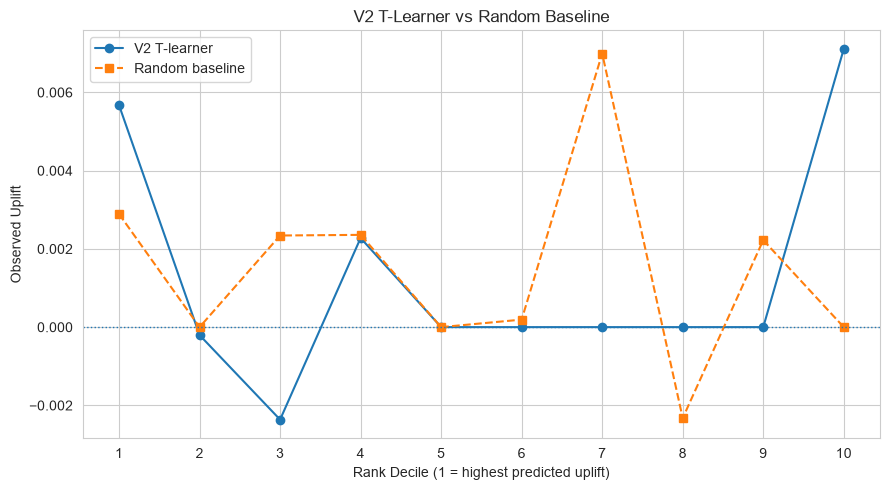

In [29]:
#v2 vs random plot
plt.figure(figsize=(9, 5))

plt.plot(
    comparison_tbl["rank"],
    comparison_tbl["v2_observed_uplift"],
    marker="o",
    label="V2 T-learner"
)

plt.plot(
    comparison_tbl["rank"],
    comparison_tbl["random_observed_uplift"],
    marker="s",
    linestyle="--",
    label="Random baseline"
)

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

plt.xlabel(
    "Rank Decile (1 = highest predicted uplift)"
)

plt.ylabel("Observed Uplift")

plt.title(
    "V2 T-Learner vs Random Baseline"
)

plt.xticks(range(1, 11))

plt.legend()

plt.tight_layout()

plt.show()

In [30]:
#final numerical check
highest_uplift = final_decile_tbl.loc[
    final_decile_tbl["rank"] == 1,
    "observed_uplift"
].iloc[0]

lowest_uplift = final_decile_tbl.loc[
    final_decile_tbl["rank"] == 10,
    "observed_uplift"
].iloc[0]

overall_uplift = (
    test_final.loc[
        test_final[TREATMENT_COL] == 1,
        LABEL_COL
    ].mean()
    -
    test_final.loc[
        test_final[TREATMENT_COL] == 0,
        LABEL_COL
    ].mean()
)

print(
    "Highest-ranked decile observed uplift:",
    highest_uplift
)

print(
    "Lowest-ranked decile observed uplift:",
    lowest_uplift
)

print(
    "Overall test-set observed uplift:",
    overall_uplift
)

Highest-ranked decile observed uplift: 0.005671761638986434
Lowest-ranked decile observed uplift: 0.0071090047393364926
Overall test-set observed uplift: 0.0014251781472684087


In [31]:
#display the final decile table
final_decile_tbl.round(6)

,uplift_decile,customers,treatment_customers,control_customers,treatment_conversions,control_conversions,treatment_conversion_rate,control_conversion_rate,observed_uplift,predicted_uplift,rank
0,9,842,441,401,8,5,0.018141,0.012469,0.005672,0.007212,1
1,8,842,439,403,1,1,0.002278,0.002481,-0.000203,0.001077,2
2,7,842,419,423,0,1,0.000000,0.002364,-0.002364,0.000650,3
3,6,842,439,403,1,0,0.002278,0.000000,0.002278,0.000518,4
4,5,842,416,426,0,0,0.000000,0.000000,0.000000,0.000452,5
5,4,842,394,448,0,0,0.000000,0.000000,0.000000,0.000407,6
6,3,842,398,444,0,0,0.000000,0.000000,0.000000,0.000378,7
7,2,842,391,451,0,0,0.000000,0.000000,0.000000,0.000353,8
8,1,842,451,391,0,0,0.000000,0.000000,0.000000,0.000322,9
9,0,842,422,420,3,0,0.007109,0.000000,0.007109,-0.000270,10


In [32]:
#display the v2 vs random comparision 
comparison_tbl.round(6)

,rank,v2_observed_uplift,random_observed_uplift
0,1,0.005672,0.002891
1,2,-0.000203,0.000000
2,3,-0.002364,0.002342
3,4,0.002278,0.002358
4,5,0.000000,0.000000
5,6,0.000000,0.000192
6,7,0.000000,0.006993
7,8,0.000000,-0.002326
8,9,0.000000,0.002224
9,10,0.007109,0.000000


In [33]:
#check whether the highest decile beats the lowest decile
top_decile = final_decile_tbl.loc[
    final_decile_tbl["rank"] == 1,
    "observed_uplift"
].iloc[0]

bottom_decile = final_decile_tbl.loc[
    final_decile_tbl["rank"] == 10,
    "observed_uplift"
].iloc[0]

print("Top decile observed uplift:", top_decile)
print("Bottom decile observed uplift:", bottom_decile)
print("Difference:", top_decile - bottom_decile)

Top decile observed uplift: 0.005671761638986434
Bottom decile observed uplift: 0.0071090047393364926
Difference: -0.0014372431003500585


In [34]:
#check monotonicity
monotonic_check = (
    final_decile_tbl["observed_uplift"]
    .diff()
    .dropna()
)

print(monotonic_check)

1   -0.005875
2   -0.002161
3    0.004642
4   -0.002278
5    0.000000
6    0.000000
7    0.000000
8    0.000000
9    0.007109
Name: observed_uplift, dtype: float64


In [35]:
#compare top vs bottom against random
random_top = random_tbl.loc[
    random_tbl["rank"] == 1,
    "observed_uplift"
].iloc[0]

random_bottom = random_tbl.loc[
    random_tbl["rank"] == 10,
    "observed_uplift"
].iloc[0]

print("V2 top decile:", top_decile)
print("Random top decile:", random_top)

print("V2 bottom decile:", bottom_decile)
print("Random bottom decile:", random_bottom)

V2 top decile: 0.005671761638986434
Random top decile: 0.0028914791723140864
V2 bottom decile: 0.0071090047393364926
Random bottom decile: 0.0


In [36]:
# Calculate total conversions in each uplift rank decile

conversion_concentration = final_decile_tbl[
    ["rank", "treatment_conversions", "control_conversions"]
].copy()

conversion_concentration["total_conversions"] = (
    conversion_concentration["treatment_conversions"]
    + conversion_concentration["control_conversions"]
)

total_test_conversions = (
    test_final[LABEL_COL].sum()
)

conversion_concentration["conversion_share"] = (
    conversion_concentration["total_conversions"]
    / total_test_conversions
)

conversion_concentration

,rank,treatment_conversions,control_conversions,total_conversions,conversion_share
0,1,8,5,13,0.65
1,2,1,1,2,0.10
2,3,0,1,1,0.05
3,4,1,0,1,0.05
4,5,0,0,0,0.00
5,6,0,0,0,0.00
6,7,0,0,0,0.00
7,8,0,0,0,0.00
8,9,0,0,0,0.00
9,10,3,0,3,0.15


In [37]:
print(
    conversion_concentration[
        [
            "rank",
            "total_conversions",
            "conversion_share"
        ]
    ].round(4)
)

   rank  total_conversions  conversion_share
0     1                 13              0.65
1     2                  2              0.10
2     3                  1              0.05
3     4                  1              0.05
4     5                  0              0.00
5     6                  0              0.00
6     7                  0              0.00
7     8                  0              0.00
8     9                  0              0.00
9    10                  3              0.15


In [38]:
rank_1 = conversion_concentration[
    conversion_concentration["rank"] == 1
].iloc[0]

print(
    f"Rank 1 conversions: "
    f"{int(rank_1['total_conversions'])}"
)

print(
    f"Rank 1 conversion share: "
    f"{rank_1['conversion_share']:.1%}"
)

print(
    f"Total test conversions: "
    f"{int(total_test_conversions)}"
)

Rank 1 conversions: 13
Rank 1 conversion share: 65.0%
Total test conversions: 20


**T-Learner Final Interpretation Summary**

**Model Configuration & Data**

* Trained separate regularized logistic regression models for treated and control groups using standardized features and $C = 0.01$.

* Evaluated on a test set containing 8,420 customers and only 20 conversions (~0.24% conversion rate), creating high sensitivity to sampling noise.


**Predicted Uplift & Calibration**

* The mean predicted uplift (~0.111 percentage points) closely aligns with the true population-level effect (~0.115 percentage points).

* Due to extreme tail predictions (-0.169 to +0.186), outputs function best as a **relative ranking score** rather than absolute treatment-effect estimates.


**Decile Performance & Conversion Concentration**

* **Rank 1 Performance:** The top decile achieved an observed uplift of +0.005672 (outperforming the +0.002891 random baseline).

* **Conversion Concentration:** Rank 1 captures **65% of all test-set conversions** (13 out of 20), providing a strong positive targeting signal.

* **Ranking Stability:** The full decile ranking is **non-monotonic** (e.g., Rank 10 produced the highest observed uplift despite negative predicted uplift), meaning the model does not consistently order customers across all deciles.


**Limitations & Conclusion**

* The tiny sample of 20 conversions prevents reliable individual-level uplift estimation or confident ranking below the top decile.

* The model provides **encouraging exploratory signal** via Rank 1 conversion concentration, but cannot be classified as beating the random baseline overall.

* **Final Verdict:** Presented as an exploratory incremental-response model; operational deployment requires a larger validation sample, cross-validation, and more robust uplift methods.

In [39]:
test_final.to_parquet(
    "../../data/samples/customer_targeting_test_final.parquet",
    index=False
)

In [40]:
import os

print(
    os.path.exists(
        "../../data/samples/customer_targeting_test_final.parquet"
    )
)

True
